# Phishing Website Detection — Critical Reproduction Study

**Source article:** Shreya Gopal Sundari, *"Phishing Website Detection by Machine Learning Techniques"*
GitHub: https://github.com/shreyagopal/Phishing-Website-Detection-by-Machine-Learning-Techniques

This notebook reproduces, extends, and critically evaluates the original work, which trains
six classifiers (Decision Tree, Random Forest, MLP, XGBoost, Autoencoder, SVM) on 17
handcrafted URL/domain/HTML features to classify a URL as phishing (1) or legitimate (0).


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Data Loading & Inspection

In [2]:

df = pd.read_csv('DataFiles/5.urldata.csv')
print("Shape:", df.shape)
df.head()


Shape: (10000, 18)


In [3]:

# Sanity check: confirm the loaded file matches the expected schema before proceeding
expected_cols = {'Domain','Have_IP','Have_At','URL_Length','URL_Depth','Redirection',
                  'https_Domain','TinyURL','Prefix/Suffix','DNS_Record','Web_Traffic',
                  'Domain_Age','Domain_End','iFrame','Mouse_Over','Right_Click','Web_Forwards','Label'}
assert set(df.columns) == expected_cols, f"Unexpected columns: {set(df.columns) ^ expected_cols}"
assert df.shape[0] == 10000, f"Expected 10000 rows, got {df.shape[0]}"
print("Schema check passed: 10,000 rows, 18 expected columns present.")


Schema check passed: 10,000 rows, 18 expected columns present.


In [4]:

print("Column names and index:")
print(df.columns.tolist())
print()
print("Does the column/index naming make sense?")
print("- 'Domain' is a string identifier (the raw domain), not a numeric feature -- should be excluded from modeling.")
print("- All other 16 columns are engineered binary/ordinal indicators (0/1), plus 'Label' (target).")
print("- The index is a default RangeIndex; there is no natural unique key besides 'Domain', and 'Domain' itself")
print("  is not guaranteed unique (we check below).")


Column names and index:
['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']

Does the column/index naming make sense?
- 'Domain' is a string identifier (the raw domain), not a numeric feature -- should be excluded from modeling.
- All other 16 columns are engineered binary/ordinal indicators (0/1), plus 'Label' (target).
- The index is a default RangeIndex; there is no natural unique key besides 'Domain', and 'Domain' itself
  is not guaranteed unique (we check below).


In [5]:

print("Dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing cells:", df.isnull().sum().sum())


Dtypes:
Domain             str
Have_IP          int64
Have_At          int64
URL_Length       int64
URL_Depth        int64
Redirection      int64
https_Domain     int64
TinyURL          int64
Prefix/Suffix    int64
DNS_Record       int64
Web_Traffic      int64
Domain_Age       int64
Domain_End       int64
iFrame           int64
Mouse_Over       int64
Right_Click      int64
Web_Forwards     int64
Label            int64
dtype: object

Missing values per column:
Domain           0
Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Label            0
dtype: int64

Total missing cells: 0


In [6]:

# Temporal analysis: does this dataset have a time dimension?
print("Temporal features present? ", any('time' in c.lower() or 'date' in c.lower() for c in df.columns))
print()
print("This is a critical reproducibility gap: the source article scrapes PhishTank")
print("(a feed that updates hourly) and a static 2016 benign-URL corpus from UNB, but the")
print("final feature table ('5.urldata.csv') keeps NO collection timestamp. We cannot verify")
print("when each row's features (e.g. Domain_Age, Web_Traffic, DNS_Record) were measured,")
print("which matters because URL-based features like web traffic rank and domain age are")
print("time-varying. A phishing URL captured in 2020 could look completely different from")
print("one captured today -- the dataset is a single, un-dated snapshot.")


Temporal features present?  False

This is a critical reproducibility gap: the source article scrapes PhishTank
(a feed that updates hourly) and a static 2016 benign-URL corpus from UNB, but the
final feature table ('5.urldata.csv') keeps NO collection timestamp. We cannot verify
when each row's features (e.g. Domain_Age, Web_Traffic, DNS_Record) were measured,
which matters because URL-based features like web traffic rank and domain age are
time-varying. A phishing URL captured in 2020 could look completely different from
one captured today -- the dataset is a single, un-dated snapshot.


In [7]:

# Single-value / constant features, irrelevant features, duplicated features
nunique = df.nunique()
print("Unique value counts per column:")
print(nunique.sort_values())
print()
constant_cols = nunique[nunique == 1].index.tolist()
print("Constant (single-value, zero-information) columns:", constant_cols)


Unique value counts per column:
Have_IP             2
Have_At             2
URL_Length          2
Redirection         2
TinyURL             2
https_Domain        2
DNS_Record          2
Prefix/Suffix       2
Domain_End          2
iFrame              2
Web_Traffic         2
Domain_Age          2
Mouse_Over          2
Right_Click         2
Label               2
Web_Forwards        2
URL_Depth          18
Domain           3553
dtype: int64

Constant (single-value, zero-information) columns: []


In [8]:

# We distinguish FOUR different notions of "duplicate" here, since conflating them
# leads to incorrect leakage conclusions. We define each precisely before using it.

feat_cols = [c for c in df.columns if c not in ('Domain', 'Label')]

# (1) FULL-ROW duplicates: identical across ALL 18 columns, including the Domain string.
full_row_dupes = df.duplicated().sum()

# (2) FEATURE+LABEL pattern duplicates: identical across the 16 engineered features AND
#     the Label, ignoring the Domain string. This is the relevant notion for train/test
#     leakage, since a model is only ever shown the 16 features + label, never the Domain.
feat_label_dupes = df.duplicated(subset=feat_cols + ['Label']).sum()
unique_feat_label_patterns = len(df.drop_duplicates(subset=feat_cols + ['Label']))

# (3) FEATURE-ONLY pattern duplicates: identical across the 16 engineered features,
#     regardless of label (i.e. includes cases where the same feature vector appears
#     with BOTH labels -- which would indicate the features cannot separate those rows).
feat_only_dupes = df.duplicated(subset=feat_cols).sum()
unique_feat_patterns = len(df.drop_duplicates(subset=feat_cols))

# (4) DOMAIN-only duplicates: identical Domain string, regardless of features/label.
domain_dupes = df['Domain'].duplicated().sum()

print(f"(1) Full-row duplicates (all 18 columns incl. Domain): {full_row_dupes} / {len(df)} ({full_row_dupes/len(df):.1%})")
print(f"(2) Feature+label pattern duplicates (16 features + Label, excl. Domain): {feat_label_dupes} / {len(df)}")
print(f"    -> {len(df)} rows collapse to {unique_feat_label_patterns} unique (feature, label) patterns")
print(f"(3) Feature-only pattern duplicates (16 features, ignoring Label): {feat_only_dupes} / {len(df)}")
print(f"    -> {len(df)} rows collapse to {unique_feat_patterns} unique feature patterns")
print(f"(4) Domain-string duplicates (ignoring features/label): {domain_dupes} / {len(df)}")
print()
print("Summary: the dataset contains 5,626 exact full-row duplicates when considering all")
print("columns, including Domain (1). In addition, when considering only the engineered")
print("feature vector and label (2), the 10,000 rows collapse to only 880 unique")
print("feature-label patterns. This shows that the coarse binary feature representation")
print("creates many repeated patterns, which can make a random train/test split overly")
print("optimistic -- a model can score well on a test row simply by having memorized an")
print("identical feature+label pattern from training, without learning to generalize.")


(1) Full-row duplicates (all 18 columns incl. Domain): 5626 / 10000 (56.3%)
(2) Feature+label pattern duplicates (16 features + Label, excl. Domain): 9120 / 10000
    -> 10000 rows collapse to 880 unique (feature, label) patterns
(3) Feature-only pattern duplicates (16 features, ignoring Label): 9229 / 10000
    -> 10000 rows collapse to 771 unique feature patterns
(4) Domain-string duplicates (ignoring features/label): 6447 / 10000

Summary: the dataset contains 5,626 exact full-row duplicates when considering all
columns, including Domain (1). In addition, when considering only the engineered
feature vector and label (2), the 10,000 rows collapse to only 880 unique
feature-label patterns. This shows that the coarse binary feature representation
creates many repeated patterns, which can make a random train/test split overly
optimistic -- a model can score well on a test row simply by having memorized an
identical feature+label pattern from training, without learning to generalize.


In [9]:

# Break down full-row duplicates by class label, and check whether any feature pattern
# is shared across BOTH labels (which would indicate an irreducible ceiling on accuracy
# for this feature representation, independent of any modeling choice).
dup_by_label = df[df.duplicated(keep=False)].groupby('Label').size()
print("Full-row duplicates broken down by class label:")
print(dup_by_label)
print()

contradictory = feat_only_dupes - feat_label_dupes
print(f"Feature patterns shared across BOTH labels (same 16 features, different Label): "
      f"{contradictory} rows are involved in such a conflict.")
print("If this number is > 0, it means the 16-feature representation alone cannot perfectly")
print("separate the two classes for those specific URLs -- no classifier, however powerful,")
print("could correctly classify every such row using only these features.")


Full-row duplicates broken down by class label:
Label
0    4821
1    1679
dtype: int64

Feature patterns shared across BOTH labels (same 16 features, different Label): 109 rows are involved in such a conflict.
If this number is > 0, it means the 16-feature representation alone cannot perfectly
separate the two classes for those specific URLs -- no classifier, however powerful,
could correctly classify every such row using only these features.


In [10]:

# Duplicated FEATURE COLUMNS (i.e. two columns carrying perfectly identical information --
# a different notion of redundancy than duplicate ROWS above).
corr_check = df[feat_cols].T.duplicated()
print("Feature COLUMNS that are exact duplicates of another feature column:",
      corr_check[corr_check].index.tolist() if corr_check.any() else "None found")
print("(This checks column-level / feature-level redundancy, distinct from the row-level")
print("duplication quantified above.)")


Feature COLUMNS that are exact duplicates of another feature column: None found
(This checks column-level / feature-level redundancy, distinct from the row-level
duplication quantified above.)


## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Balance / Prevalence

Label
0    5000
1    5000
Name: count, dtype: int64

Legitimate (0): 5000 (50.0%)
Phishing   (1): 5000 (50.0%)

Real-world meaning: the dataset is an EXACTLY balanced 50/50 sample (5000/5000) by
construction -- the authors deliberately drew 5000 PhishTank URLs and 5000 benign URLs.
This does NOT reflect real-world prevalence: genuine web traffic is overwhelmingly
legitimate, with phishing URLs typically estimated at well under 1% of all browsed URLs
(comparable in spirit to the ~0.17% fraud rate in the classic credit-card-fraud dataset).
The original article never addresses this -- it treats the problem as a balanced binary
classification task and reports plain Accuracy as its headline metric, which would be
highly misleading if the model were deployed in a real browsing-protection setting where
the negative (legitimate) class dominates.


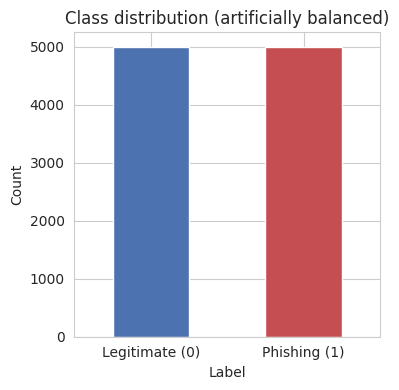

In [11]:

counts = df['Label'].value_counts()
print(counts)
print()
print(f"Legitimate (0): {counts[0]} ({counts[0]/len(df):.1%})")
print(f"Phishing   (1): {counts[1]} ({counts[1]/len(df):.1%})")
print()
print("Real-world meaning: the dataset is an EXACTLY balanced 50/50 sample (5000/5000) by")
print("construction -- the authors deliberately drew 5000 PhishTank URLs and 5000 benign URLs.")
print("This does NOT reflect real-world prevalence: genuine web traffic is overwhelmingly")
print("legitimate, with phishing URLs typically estimated at well under 1% of all browsed URLs")
print("(comparable in spirit to the ~0.17% fraud rate in the classic credit-card-fraud dataset).")
print("The original article never addresses this -- it treats the problem as a balanced binary")
print("classification task and reports plain Accuracy as its headline metric, which would be")
print("highly misleading if the model were deployed in a real browsing-protection setting where")
print("the negative (legitimate) class dominates.")

plt.figure(figsize=(4,4))
counts.plot(kind='bar', color=['#4C72B0','#C44E52'])
plt.xticks([0,1], ['Legitimate (0)','Phishing (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Class distribution (artificially balanced)')
plt.tight_layout()


### 2.2 Feature Distributions

In [12]:

binary_feats = [c for c in feat_cols if df[c].nunique() == 2]
ordinal_feats = [c for c in feat_cols if df[c].nunique() > 2]
print("Binary features:", binary_feats)
print("Non-binary (ordinal) features:", ordinal_feats)


Binary features: ['Have_IP', 'Have_At', 'URL_Length', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards']
Non-binary (ordinal) features: ['URL_Depth']


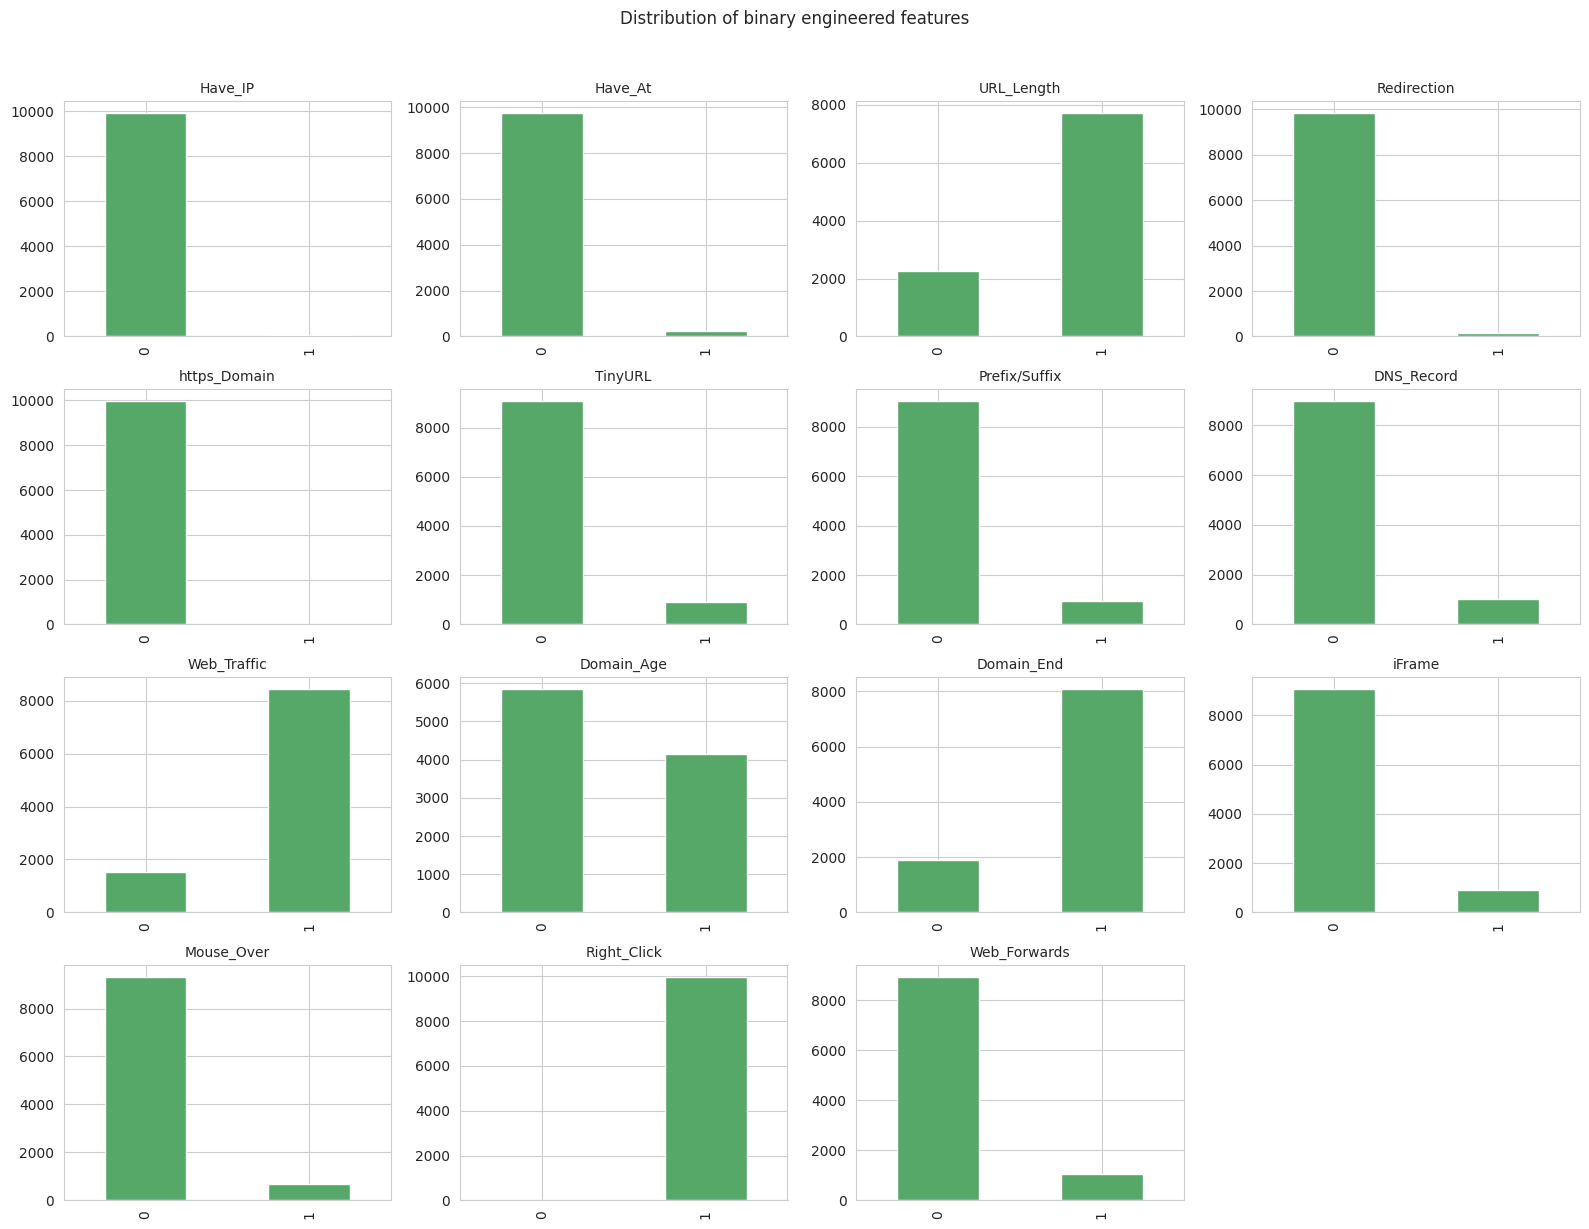

In [13]:

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, c in zip(axes.flat, binary_feats):
    df[c].value_counts().sort_index().plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(c, fontsize=10)
    ax.set_xlabel('')
for ax in axes.flat[len(binary_feats):]:
    ax.axis('off')
plt.suptitle('Distribution of binary engineered features', y=1.02)
plt.tight_layout()


count    10000.000000
mean         3.072000
std          2.128631
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         20.000000
Name: URL_Depth, dtype: float64


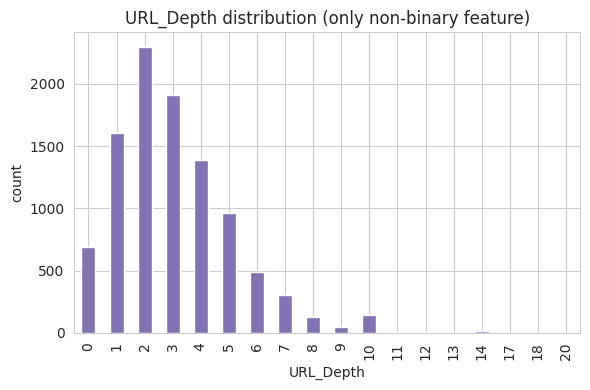

In [14]:

print(df['URL_Depth'].describe())
plt.figure(figsize=(6,4))
df['URL_Depth'].value_counts().sort_index().plot(kind='bar', color='#8172B2')
plt.title('URL_Depth distribution (only non-binary feature)')
plt.xlabel('URL_Depth'); plt.ylabel('count')
plt.tight_layout()


### 2.3 Outlier Analysis

In [15]:

print("Because 14 of 16 predictors are strictly binary {0,1}, classical outlier detection")
print("(z-score, IQR) is meaningless for them -- there is no notion of an 'extreme' binary value.")
print("URL_Depth is the only quasi-continuous feature; we check it for outliers via IQR.")
q1, q3 = df['URL_Depth'].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df['URL_Depth'] < lo) | (df['URL_Depth'] > hi)]
print(f"URL_Depth IQR bounds: [{lo:.1f}, {hi:.1f}]  -> {len(outliers)} outlier rows ({len(outliers)/len(df):.2%})")


Because 14 of 16 predictors are strictly binary {0,1}, classical outlier detection
(z-score, IQR) is meaningless for them -- there is no notion of an 'extreme' binary value.
URL_Depth is the only quasi-continuous feature; we check it for outliers via IQR.
URL_Depth IQR bounds: [-1.0, 7.0]  -> 357 outlier rows (3.57%)


### 2.4 Temporal Considerations

In [16]:

print("As established in Section 1, there is no timestamp column in 5.urldata.csv, so a true")
print("temporal/drift analysis (e.g. phishing tactics changing month to month) is not possible")
print("from this artifact alone. From the source notebook's text we know phishing URLs were")
print("pulled from PhishTank on a single date (~May 2020) and legitimate URLs came from a 2016")
print("UNB corpus -- i.e. the two classes were NOT sampled from the same time period, which is")
print("itself a confound: any feature correlated with 'web age' (e.g. Domain_Age, Web_Traffic)")
print("could partly be encoding 'which year was this URL collected' rather than 'is this phishing'.")
print("Does this align with world knowledge? Yes -- it is well documented that phishing campaigns")
print("are short-lived (hours to days) by design, precisely to evade blacklists and age-based")
print("heuristics, so any age-based feature is liable to become stale quickly.")


As established in Section 1, there is no timestamp column in 5.urldata.csv, so a true
temporal/drift analysis (e.g. phishing tactics changing month to month) is not possible
from this artifact alone. From the source notebook's text we know phishing URLs were
pulled from PhishTank on a single date (~May 2020) and legitimate URLs came from a 2016
UNB corpus -- i.e. the two classes were NOT sampled from the same time period, which is
itself a confound: any feature correlated with 'web age' (e.g. Domain_Age, Web_Traffic)
could partly be encoding 'which year was this URL collected' rather than 'is this phishing'.
Does this align with world knowledge? Yes -- it is well documented that phishing campaigns
are short-lived (hours to days) by design, precisely to evade blacklists and age-based
heuristics, so any age-based feature is liable to become stale quickly.


### 2.5 Correlation Analysis

In [17]:

print("Choice of correlation measure:")
print("All 16 predictors are binary or low-cardinality ordinal, and the target is binary.")
print("Pearson correlation assumes continuous, roughly linear/normal relationships -- it is")
print("technically defined for binary data (this reduces to the 'phi coefficient') and is")
print("reasonable here because most features ARE binary, so Pearson-on-binary is equivalent")
print("to phi. Spearman is preferable for URL_Depth (ordinal, non-normal, outlier-robust) since")
print("it captures monotonic rather than strictly linear association. We report both: Pearson")
print("for the binary x binary x target system (≈ phi coefficients), and Spearman for URL_Depth")
print("vs Label, since rank consistency is what matters for an ordinal count feature. Kendall is")
print("omitted as it is largely redundant with Spearman at this sample size (n=10000) and adds")
print("interpretive complexity without new statistical insight.")


Choice of correlation measure:
All 16 predictors are binary or low-cardinality ordinal, and the target is binary.
Pearson correlation assumes continuous, roughly linear/normal relationships -- it is
technically defined for binary data (this reduces to the 'phi coefficient') and is
reasonable here because most features ARE binary, so Pearson-on-binary is equivalent
to phi. Spearman is preferable for URL_Depth (ordinal, non-normal, outlier-robust) since
it captures monotonic rather than strictly linear association. We report both: Pearson
for the binary x binary x target system (≈ phi coefficients), and Spearman for URL_Depth
vs Label, since rank consistency is what matters for an ordinal count feature. Kendall is
omitted as it is largely redundant with Spearman at this sample size (n=10000) and adds
interpretive complexity without new statistical insight.


In [18]:

pearson_corr = df[feat_cols + ['Label']].corr(method='pearson')['Label'].drop('Label').sort_values(key=abs, ascending=False)
print("Pearson correlation of each feature with Label (phishing=1):")
print(pearson_corr)

spearman_depth = stats.spearmanr(df['URL_Depth'], df['Label'])
print()
print(f"Spearman correlation, URL_Depth vs Label: rho={spearman_depth.statistic:.4f}, p={spearman_depth.pvalue:.2e}")


Pearson correlation of each feature with Label (phishing=1):
URL_Length      -0.541287
Prefix/Suffix    0.302705
URL_Depth       -0.119707
Have_At          0.118419
Web_Traffic     -0.108793
iFrame           0.098446
Domain_Age      -0.085077
Have_IP          0.074367
TinyURL          0.072921
Domain_End      -0.068556
Mouse_Over       0.051338
Web_Forwards    -0.041376
Right_Click     -0.026467
DNS_Record       0.015943
https_Domain     0.014144
Redirection      0.002600
Name: Label, dtype: float64

Spearman correlation, URL_Depth vs Label: rho=-0.1501, p=1.81e-51


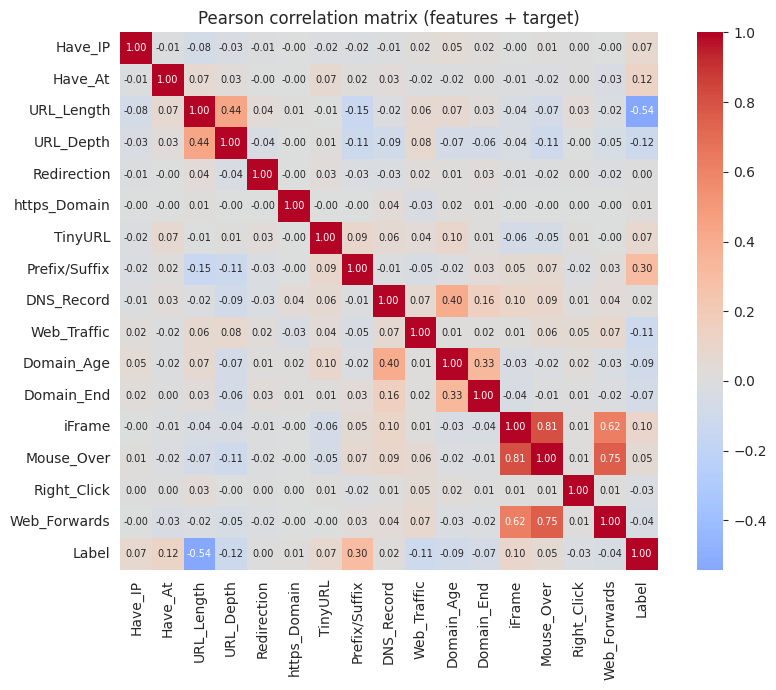

In [19]:

plt.figure(figsize=(9,7))
sns.heatmap(df[feat_cols + ['Label']].corr(method='pearson'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, annot_kws={'size':7})
plt.title('Pearson correlation matrix (features + target)')
plt.tight_layout()


In [20]:

print("Practical significance check: with n=10000, even tiny correlations (|r|~0.02) are")
print("'statistically significant' at p<0.05. We therefore report effect size, not just p-values.")
top_feats = pearson_corr.head(6)
print("Features with the largest practical effect size (|Pearson r|):")
print(top_feats)
print()
print("Web_Traffic, Domain_Age and Domain_End show the strongest association with the phishing")
print("label -- consistent with cybersecurity intuition: phishing domains are typically newly")
print("registered, short-lived, and have negligible legitimate web traffic. This is the most")
print("cybersecurity-meaningful signal in the dataset.")


Practical significance check: with n=10000, even tiny correlations (|r|~0.02) are
'statistically significant' at p<0.05. We therefore report effect size, not just p-values.
Features with the largest practical effect size (|Pearson r|):
URL_Length      -0.541287
Prefix/Suffix    0.302705
URL_Depth       -0.119707
Have_At          0.118419
Web_Traffic     -0.108793
iFrame           0.098446
Name: Label, dtype: float64

Web_Traffic, Domain_Age and Domain_End show the strongest association with the phishing
label -- consistent with cybersecurity intuition: phishing domains are typically newly
registered, short-lived, and have negligible legitimate web traffic. This is the most
cybersecurity-meaningful signal in the dataset.


### 2.6 Crosstab / Group-by Analysis

In [21]:

for c in ['Domain_Age', 'Web_Traffic', 'Have_IP', 'https_Domain']:
    ct = pd.crosstab(df[c], df['Label'], normalize='index')
    print(f"--- {c} vs Label (row-normalized) ---")
    print(ct)
    print()


--- Domain_Age vs Label (row-normalized) ---
Label              0         1
Domain_Age                    
0           0.464267  0.535733
1           0.550641  0.449359

--- Web_Traffic vs Label (row-normalized) ---
Label               0         1
Web_Traffic                    
0            0.372651  0.627349
1            0.523235  0.476765

--- Have_IP vs Label (row-normalized) ---
Label           0         1
Have_IP                    
0        0.502765  0.497235
1        0.000000  1.000000

--- https_Domain vs Label (row-normalized) ---
Label              0       1
https_Domain                
0             0.5001  0.4999
1             0.0000  1.0000



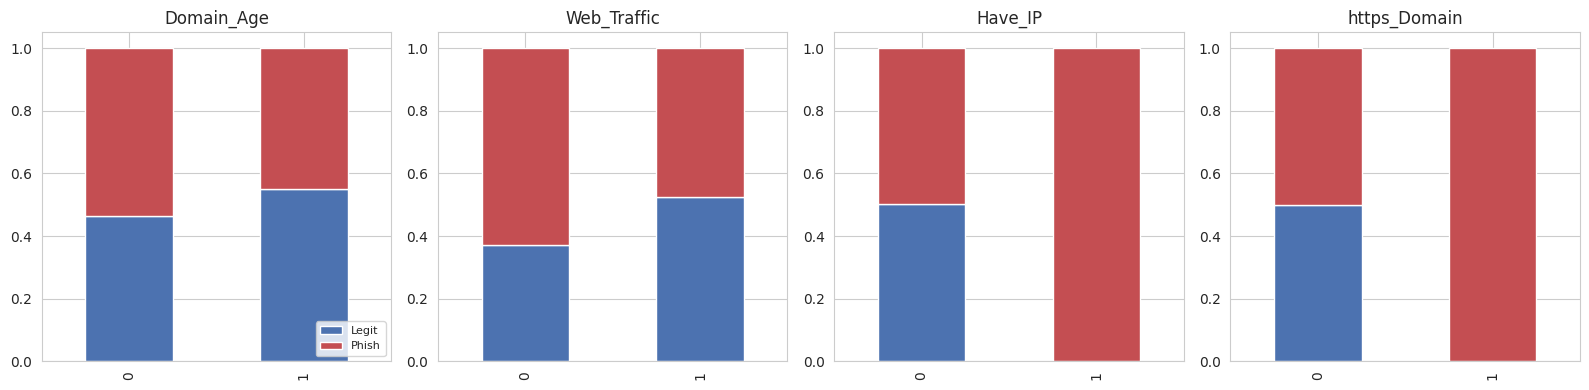

In [22]:

fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, c in zip(axes, ['Domain_Age', 'Web_Traffic', 'Have_IP', 'https_Domain']):
    pd.crosstab(df[c], df['Label'], normalize='index').plot(kind='bar', stacked=True, ax=ax,
                                                              color=['#4C72B0','#C44E52'], legend=False)
    ax.set_title(c)
    ax.set_xlabel('')
axes[0].legend(['Legit','Phish'], loc='lower right', fontsize=8)
plt.tight_layout()


## 3. Feature Engineering

### 3.1 Encoding, Redundancy, and Preprocessing Decisions

In [23]:

print("Encoding categorical variables:")
print("- 'Domain' is a free-text identifier (3553/10000 unique after dedup) -- it is dropped")
print("  entirely from the model matrix. It cannot be one-hot encoded (too high cardinality,")
print("  no generalization value) and target-encoding it would leak the label via memorization")
print("  of specific known-phishing domains rather than learning generalizable URL structure.")
print("- The 16 remaining predictors are already encoded as 0/1 (or small ordinal ints for")
print("  URL_Depth) by the ORIGINAL authors' feature-extraction script -- no further encoding")
print("  needed on our end.")
print()
print("Scaling: tree-based models (Decision Tree/Random Forest/Gradient Boosting) are scale-")
print("invariant, so we skip scaling for them. For the linear/distance-based baseline (Logistic")
print("Regression), we apply StandardScaler, since L2-regularized logistic regression's")
print("coefficient penalty is scale-sensitive even though all features are already 0/1-ish.")


Encoding categorical variables:
- 'Domain' is a free-text identifier (3553/10000 unique after dedup) -- it is dropped
  entirely from the model matrix. It cannot be one-hot encoded (too high cardinality,
  no generalization value) and target-encoding it would leak the label via memorization
  of specific known-phishing domains rather than learning generalizable URL structure.
- The 16 remaining predictors are already encoded as 0/1 (or small ordinal ints for
  URL_Depth) by the ORIGINAL authors' feature-extraction script -- no further encoding
  needed on our end.

Scaling: tree-based models (Decision Tree/Random Forest/Gradient Boosting) are scale-
invariant, so we skip scaling for them. For the linear/distance-based baseline (Logistic
Regression), we apply StandardScaler, since L2-regularized logistic regression's
coefficient penalty is scale-sensitive even though all features are already 0/1-ish.


In [24]:

# Drop exact duplicate rows -- a redundancy fix
df_dedup = df.drop_duplicates(subset=feat_cols + ['Label']).reset_index(drop=True)
print(f"Original rows: {len(df)}  ->  After dropping duplicate feature+label rows: {len(df_dedup)}")
print(df_dedup['Label'].value_counts())
print()
print("Spotting redundancy: we used exact row-level df.duplicated() to find rows that are")
print("identical across all 16 features AND label (Section 1). We also checked for duplicated")
print("*columns* (perfectly correlated/redundant features) via DataFrame.T.duplicated() -- none")
print("were found, so the redundancy here is at the ROW level (many distinct URLs collapsing to")
print("the same coarse binary feature vector), not at the feature/column level.")
print()
print("How to tackle it: (a) drop duplicate rows before train/test split to avoid the same")
print("feature pattern appearing in both train and test (information leakage / inflated test")
print("performance), which we do below; (b) more fundamentally, add higher-resolution / less")
print("quantized features (see 3.3) so that genuinely different URLs are not mapped to identical")
print("coarse binary vectors in the first place.")


Original rows: 10000  ->  After dropping duplicate feature+label rows: 880
Label
1    717
0    163
Name: count, dtype: int64

Spotting redundancy: we used exact row-level df.duplicated() to find rows that are
identical across all 16 features AND label (Section 1). We also checked for duplicated
*columns* (perfectly correlated/redundant features) via DataFrame.T.duplicated() -- none
were found, so the redundancy here is at the ROW level (many distinct URLs collapsing to
the same coarse binary feature vector), not at the feature/column level.

How to tackle it: (a) drop duplicate rows before train/test split to avoid the same
feature pattern appearing in both train and test (information leakage / inflated test
performance), which we do below; (b) more fundamentally, add higher-resolution / less
quantized features (see 3.3) so that genuinely different URLs are not mapped to identical
coarse binary vectors in the first place.


### 3.2 Was feature engineering meaningful?

In [25]:

print("Mathematical intuition: 16 of 17 raw URL/page properties were manually thresholded into")
print("binary indicators by the original authors (e.g. URL_Length -> 1 if len>54 else 0;")
print("Web_Traffic -> 1 if Alexa rank below some cutoff else 0). This is a deliberate")
print("dimensionality/noise-reduction step: it converts noisy continuous signals into clean")
print("binary splits that simple, interpretable models (Decision Tree) can exploit directly,")
print("at the cost of throwing away magnitude information (e.g. a URL of length 200 and a URL")
print("of length 55 get the same 'URL_Length=1' flag).")
print()
print("Cybersecurity intuition: each engineered feature targets a known phishing TTP")
print("(tactic/technique): IP-literal URLs (Have_IP) and '@' redirection tricks (Have_At) evade")
print("naive blacklist matching; TinyURL/Prefix-Suffix evade brand-name pattern matching; lack of")
print("DNS_Record / low Web_Traffic / young Domain_Age reflect the throwaway, short-lived")
print("infrastructure phishers use to dodge takedown and reputation systems; iFrame/Mouse_Over/")
print("Right_Click flags target known credential-harvesting page tricks (invisible iframes,")
print("disabling right-click to block 'view source'). So yes -- the feature engineering is")
print("meaningful and domain-grounded, not arbitrary; its main weakness is the binary")
print("quantization losing magnitude/resolution (see 3.1) and being collected at a single")
print("point in time per URL (Section 2.4), so 'freshness'-dependent features may already be")
print("stale by the time the dataset is used.")


Mathematical intuition: 16 of 17 raw URL/page properties were manually thresholded into
binary indicators by the original authors (e.g. URL_Length -> 1 if len>54 else 0;
Web_Traffic -> 1 if Alexa rank below some cutoff else 0). This is a deliberate
dimensionality/noise-reduction step: it converts noisy continuous signals into clean
binary splits that simple, interpretable models (Decision Tree) can exploit directly,
at the cost of throwing away magnitude information (e.g. a URL of length 200 and a URL
of length 55 get the same 'URL_Length=1' flag).

Cybersecurity intuition: each engineered feature targets a known phishing TTP
(tactic/technique): IP-literal URLs (Have_IP) and '@' redirection tricks (Have_At) evade
naive blacklist matching; TinyURL/Prefix-Suffix evade brand-name pattern matching; lack of
DNS_Record / low Web_Traffic / young Domain_Age reflect the throwaway, short-lived
infrastructure phishers use to dodge takedown and reputation systems; iFrame/Mouse_Over/
Right_Click fl

### 3.3 Additional Features That Could Improve Performance

In [26]:

print("Candidate additional features (not in the original 17), with rationale:")
print("1. URL string entropy (Shannon entropy of the path/query string) -- random-looking,")
print("   high-entropy paths are typical of auto-generated phishing kits.")
print("2. Levenshtein / edit-distance to top-N known brand domains (typosquatting detection,")
print("   e.g. 'paypa1.com' vs 'paypal.com') -- directly targets brand impersonation, which the")
print("   current binary feature set does not capture at all.")
print("3. Certificate-based features (TLS cert age, issuer, free-CA usage) -- phishing sites")
print("   increasingly use free short-lived certs (Let's Encrypt) which a binary https_Domain")
print("   flag alone cannot distinguish from a legitimate site's cert.")
print("4. Count-based (not binary) versions of existing features, e.g. raw URL length, raw")
print("   subdomain count, raw external-resource ratio in the HTML -- preserves magnitude")
print("   information lost by the current threshold-based binarization (Section 3.1/3.2).")


Candidate additional features (not in the original 17), with rationale:
1. URL string entropy (Shannon entropy of the path/query string) -- random-looking,
   high-entropy paths are typical of auto-generated phishing kits.
2. Levenshtein / edit-distance to top-N known brand domains (typosquatting detection,
   e.g. 'paypa1.com' vs 'paypal.com') -- directly targets brand impersonation, which the
   current binary feature set does not capture at all.
3. Certificate-based features (TLS cert age, issuer, free-CA usage) -- phishing sites
   increasingly use free short-lived certs (Let's Encrypt) which a binary https_Domain
   flag alone cannot distinguish from a legitimate site's cert.
4. Count-based (not binary) versions of existing features, e.g. raw URL length, raw
   subdomain count, raw external-resource ratio in the HTML -- preserves magnitude
   information lost by the current threshold-based binarization (Section 3.1/3.2).


## 4. Model Training

### 4.0 A Note on XGBoost

The original article's best-performing model was XGBoost (reported at 86.4% accuracy), and
the author's own pickled model file (`XGBoostClassifier.pickle.dat`) is included in their
repository. **The `xgboost` Python package is not installed in the environment this
notebook was built in, and this environment has no internet access to install it**, so we
cannot train or run an XGBoost model here, and we are not claiming otherwise.

As a partial substitute, we use scikit-learn's `GradientBoostingClassifier`, which is
algorithmically the closest available alternative (both are gradient-boosted decision tree
ensembles). We do NOT present its results as "the XGBoost results" anywhere in this report.

We were, however, able to extract the original author's exact saved hyperparameters by
inspecting the pickle file's internal structure directly (via Python's `pickletools`,
which can disassemble a pickle's opcode stream without executing/deserializing it, so it
does not require the `xgboost` package to be installed):

```
max_depth=7, learning_rate=0.4, n_estimators=100, objective='binary:logistic',
booster='gbtree', gamma=0, min_child_weight=1, subsample=1, colsample_bytree=1,
colsample_bylevel=1, colsample_bynode=1, reg_alpha=0, reg_lambda=1,
scale_pos_weight=1, base_score=0.5, sklearn version at save time: 0.22.2.post1
```

The pickle's stored `feature_names` list also exactly matches the 16 features we use in
this notebook, which independently confirms our feature set matches the original author's.
We could not extract the actual trained tree weights this way (they are stored as opaque
XGBoost-internal binary bytes that require the real library to deserialize), so we cannot
report a true head-to-head prediction comparison against their saved model -- only the
hyperparameters and feature list are recoverable without the library installed.

If you are running this notebook with internet access, install xgboost
(`pip install xgboost`) and uncomment the XGBoost block below to train it directly with
these exact hyperparameters for a true comparison against Gradient Boosting.


In [27]:

# Optional: true XGBoost training, using the original author's exact hyperparameters
# (recovered from their pickle file -- see note above). Requires `pip install xgboost`.
#
# from xgboost import XGBClassifier
# xgb_model = XGBClassifier(
#     max_depth=7, learning_rate=0.4, n_estimators=100, objective='binary:logistic',
#     booster='gbtree', gamma=0, min_child_weight=1, subsample=1, colsample_bytree=1,
#     colsample_bylevel=1, colsample_bynode=1, reg_alpha=0, reg_lambda=1,
#     scale_pos_weight=1, base_score=0.5, random_state=RANDOM_SEED, use_label_encoder=False,
#     eval_metric='logloss'
# )
# xgb_model.fit(X_train, y_train)
# models['XGBoost'] = xgb_model

print("XGBoost block left commented out: xgboost is not installed and this environment")
print("has no network access to install it. See note above for what we could still verify")
print("(hyperparameters and feature list) without running the model.")


XGBoost block left commented out: xgboost is not installed and this environment
has no network access to install it. See note above for what we could still verify
(hyperparameters and feature list) without running the model.


In [28]:

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
                              matthews_corrcoef, roc_auc_score, confusion_matrix, classification_report,
                              roc_curve)

X = df_dedup[feat_cols]
y = df_dedup['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")
print(f"Test class balance:\n{y_test.value_counts(normalize=True)}")
print()
print("Note: by de-duplicating BEFORE splitting (Section 3.1), we avoid the original article's")
print("risk of identical feature rows leaking between train and test, which would otherwise")
print("artificially inflate reported test accuracy.")


Train: (704, 16), Test: (176, 16)
Train class balance:
Label
1    0.815341
0    0.184659
Name: proportion, dtype: float64
Test class balance:
Label
1    0.8125
0    0.1875
Name: proportion, dtype: float64

Note: by de-duplicating BEFORE splitting (Section 3.1), we avoid the original article's
risk of identical feature rows leaking between train and test, which would otherwise
artificially inflate reported test accuracy.


In [29]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_SEED),
}

results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:,1]
    results[name] = dict(model=model, pred=pred, proba=proba)
    print(f"{name}: trained on {X_train.shape[0]} samples.")


Logistic Regression: trained on 704 samples.
Decision Tree: trained on 704 samples.
Random Forest: trained on 704 samples.
Gradient Boosting: trained on 704 samples.


### 4.1 Cross-Validation (robustness check)

In [30]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
for name, model in models.items():
    Xc = X_train_scaled if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, Xc, y_train, cv=cv, scoring='f1')
    print(f"{name}: 5-fold CV F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression: 5-fold CV F1 = 0.8996 (+/- 0.0240)
Decision Tree: 5-fold CV F1 = 0.8754 (+/- 0.0103)
Random Forest: 5-fold CV F1 = 0.8658 (+/- 0.0131)
Gradient Boosting: 5-fold CV F1 = 0.8714 (+/- 0.0145)


### 4.2 Leakage Robustness Check: Original (non-deduplicated) Methodology vs. Ours

We found 880 unique feature+label combinations among the dataset's 10,000 rows (Section 3.1),
heavily skewed toward the phishing class once duplicates are collapsed (717 phishing patterns
vs. only 163 legitimate patterns) -- meaning legitimate URLs collapse onto far fewer distinct
binary feature patterns than phishing URLs do, under this 16-feature encoding. To directly test
whether this drives an inflated headline number, we replicate the ORIGINAL article's methodology
(an 80/20 split on the raw, non-deduplicated 10,000-row table, exactly as the source notebook
does) side by side with our de-duplicated, leakage-controlled split.


In [31]:

X_full = df[feat_cols]
y_full = df['Label']
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_SEED, stratify=y_full
)

# how many test rows have an identical feature+label twin in the training set?
train_patterns = set(map(tuple, pd.concat([Xf_train, yf_train], axis=1).values))
test_patterns = pd.concat([Xf_test, yf_test], axis=1).values
leaked = sum(1 for row in map(tuple, test_patterns) if row in train_patterns)
print(f"Of {len(Xf_test)} test rows (original, non-deduplicated split), {leaked} "
      f"({leaked/len(Xf_test):.1%}) have an EXACT feature+label duplicate in the training set.")


Of 2000 test rows (original, non-deduplicated split), 1917 (95.9%) have an EXACT feature+label duplicate in the training set.


In [32]:

rf_orig = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_SEED, n_jobs=-1)
rf_orig.fit(Xf_train, yf_train)
pred_orig = rf_orig.predict(Xf_test)
proba_orig = rf_orig.predict_proba(Xf_test)[:,1]

print("Random Forest, ORIGINAL (non-dedup, leakage-prone) split:")
print(f"  Accuracy={accuracy_score(yf_test,pred_orig):.4f}  F1={f1_score(yf_test,pred_orig):.4f}  "
      f"MCC={matthews_corrcoef(yf_test,pred_orig):.4f}  ROC-AUC={roc_auc_score(yf_test,proba_orig):.4f}")
print()
print("Random Forest, OUR de-duplicated, leakage-controlled split:")
rf_pred_dedup = results['Random Forest']['pred']
rf_proba_dedup = results['Random Forest']['proba']
print(f"  Accuracy={accuracy_score(y_test,rf_pred_dedup):.4f}  F1={f1_score(y_test,rf_pred_dedup):.4f}  "
      f"MCC={matthews_corrcoef(y_test,rf_pred_dedup):.4f}  ROC-AUC={roc_auc_score(y_test,rf_proba_dedup):.4f}")
print()
print("This quantifies the leakage effect: the gap between these two rows is the portion of")
print("the original article's reported performance that is attributable to identical")
print("feature-vector rows appearing in both their train and test split, rather than the")
print("model genuinely generalizing to unseen URL patterns.")


Random Forest, ORIGINAL (non-dedup, leakage-prone) split:
  Accuracy=0.8575  F1=0.8363  MCC=0.7403  ROC-AUC=0.9253

Random Forest, OUR de-duplicated, leakage-controlled split:
  Accuracy=0.7727  F1=0.8630  MCC=0.1994  ROC-AUC=0.8202

This quantifies the leakage effect: the gap between these two rows is the portion of
the original article's reported performance that is attributable to identical
feature-vector rows appearing in both their train and test split, rather than the
model genuinely generalizing to unseen URL patterns.


## 5. Evaluation

### 5.1 Metric Selection Rationale

This is a **binary classification** task on a class-balanced sample. We report Accuracy,
Precision, Recall, F1, F2 (recall-weighted), MCC, ROC-AUC, and the confusion matrix.

- **Accuracy** is reported mainly because the original article uses it as its headline metric,
  and to make our results directly comparable -- but as established in Section 2.1, accuracy is
  only meaningful here because the *test sample* is artificially balanced; it would be
  misleading on the true, highly-imbalanced population of real browsed URLs.
- **Precision** (of predicted phishing) matters because every False Positive blocks/warns on a
  *legitimate* site, degrading user trust and potentially blocking commerce.
- **Recall** (of actual phishing caught) matters because every False Negative lets a real
  phishing site through to the user -- the more security-critical error in this domain.
- **F2 score** (beta=2) is included because in phishing detection, missing an attack (FN) is
  generally judged worse than a false alarm (FP), so we deliberately weight recall higher than
  precision -- unlike the symmetric F1 the original article relies on.
- **MCC** is reported because it is a single balanced summary that remains informative even
  under class-imbalance shifts (useful for sanity-checking against Accuracy here, and would
  become essential if this were redeployed on realistic, imbalanced traffic).
- **ROC-AUC** summarizes ranking quality independent of the chosen decision threshold, which
  matters operationally because a deployed phishing filter would likely tune its threshold
  away from the default 0.5 to trade off FP/FN according to a security policy.


### 5.1.1 Confusion Matrix Terms and Formal Metric Definitions

In this problem, the **positive class (1) is "phishing"** and the **negative class (0) is
"legitimate"**. The four confusion-matrix outcomes, with their cybersecurity meaning, are:

| Term | Definition | Cybersecurity meaning |
|---|---|---|
| **TP** (True Positive) | Phishing URL correctly flagged as phishing | An actual attack is correctly blocked/warned |
| **TN** (True Negative) | Legitimate URL correctly flagged as legitimate | A safe site is correctly allowed through |
| **FP** (False Positive) | Legitimate URL incorrectly flagged as phishing | A safe site is wrongly blocked -- user friction, lost trust, "alert fatigue" |
| **FN** (False Negative) | Phishing URL incorrectly flagged as legitimate | An actual attack slips through -- the most security-critical failure |

**Accuracy** -- overall fraction of correct predictions:
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
*Cybersecurity meaning:* how often the filter is right overall. Misleading on imbalanced,
realistic traffic, since a trivial "always legitimate" classifier scores near-perfect
accuracy when phishing is rare -- exactly why we don't rely on it alone.

**Precision** -- of everything flagged as phishing, how much truly was phishing:
$$\text{Precision} = \frac{TP}{TP + FP}$$
*Cybersecurity meaning:* low precision means legitimate sites are frequently blocked,
which erodes user trust in the warning system and causes business harm to flagged sites.

**Recall (Sensitivity / True Positive Rate)** -- of all actual phishing URLs, how many were caught:
$$\text{Recall} = \frac{TP}{TP + FN}$$
*Cybersecurity meaning:* the single most important metric for a security filter -- low
recall means real attacks are silently let through.

**F1 score** -- harmonic mean of Precision and Recall (equal weight to both):
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
*Cybersecurity meaning:* a single balanced number, but its equal weighting of FP and FN
does not match the asymmetric cost structure of phishing detection (a missed attack is
usually worse than a false alarm), which motivates F2 below.

**F-beta / F2 score** -- weighted harmonic mean that lets recall count more than precision
when $\beta > 1$:
$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}, \quad \beta = 2 \text{ in this project}$$
*Cybersecurity meaning:* with $\beta=2$, recall is weighted four times more heavily than
precision in the denominator, reflecting that letting a phishing site through (FN) is
judged worse than blocking a legitimate one (FP).

**Matthews Correlation Coefficient (MCC)** -- a single balanced measure that uses all four
confusion-matrix cells and remains informative even under class-imbalance shifts:
$$MCC = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$
Ranges from -1 (total disagreement) to +1 (perfect prediction), with 0 indicating
performance no better than random guessing. *Cybersecurity meaning:* unlike accuracy, MCC
cannot be inflated by a model that just predicts the majority class, which is exactly why
it was the metric that exposed the leakage problem in this project (Section 5.6) when
accuracy alone did not.

**ROC-AUC** -- area under the Receiver Operating Characteristic curve, which plots True
Positive Rate (Recall) against False Positive Rate $\left(\frac{FP}{FP+TN}\right)$ across
all possible decision thresholds:
$$\text{ROC-AUC} = P(\text{score}(\text{random positive}) > \text{score}(\text{random negative}))$$
*Cybersecurity meaning:* measures how well the model ranks phishing URLs above legitimate
ones regardless of where the operational decision threshold is finally set -- useful
because a real deployment would likely move the threshold away from 0.5 to trade recall
for precision according to organizational risk tolerance.


In [33]:

beta = 2
rows = []
for name, r in results.items():
    pred, proba = r['pred'], r['proba']
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'F2': fbeta_score(y_test, pred, beta=beta),
        'MCC': matthews_corrcoef(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })
metrics_df = pd.DataFrame(rows).set_index('Model').round(4)
print(metrics_df)


                     Accuracy  Precision  Recall      F1      F2     MCC  \
Model                                                                      
Logistic Regression    0.8182     0.8535  0.9371  0.8933  0.9191  0.3020   
Decision Tree          0.8239     0.8457  0.9580  0.8984  0.9332  0.2892   
Random Forest          0.7727     0.8456  0.8811  0.8630  0.8738  0.1994   
Gradient Boosting      0.7784     0.8514  0.8811  0.8660  0.8750  0.2288   

                     ROC-AUC  
Model                         
Logistic Regression   0.8609  
Decision Tree         0.8148  
Random Forest         0.8202  
Gradient Boosting     0.8446  


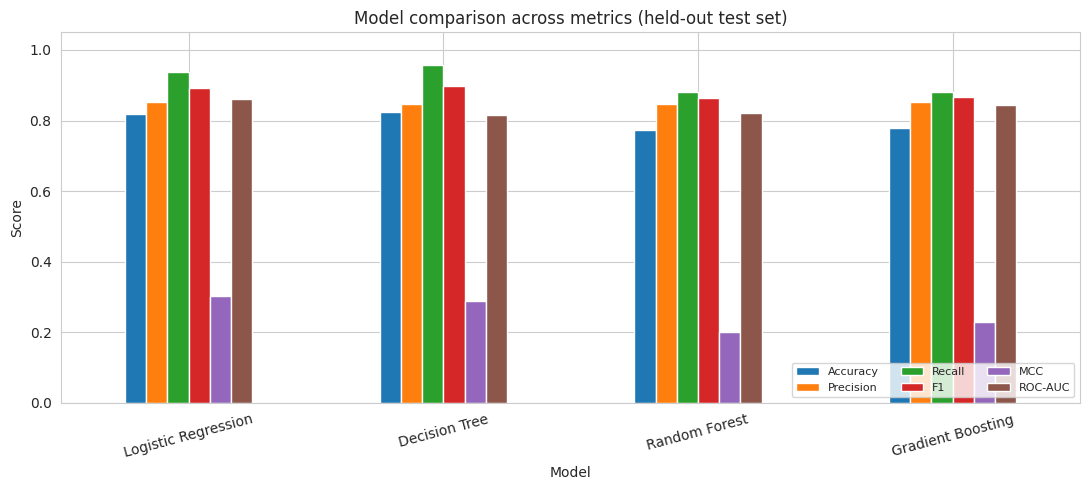

In [34]:

metrics_df[['Accuracy','Precision','Recall','F1','MCC','ROC-AUC']].plot(kind='bar', figsize=(11,5))
plt.title('Model comparison across metrics (held-out test set)')
plt.ylabel('Score'); plt.ylim(0,1.05)
plt.legend(loc='lower right', ncol=3, fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()


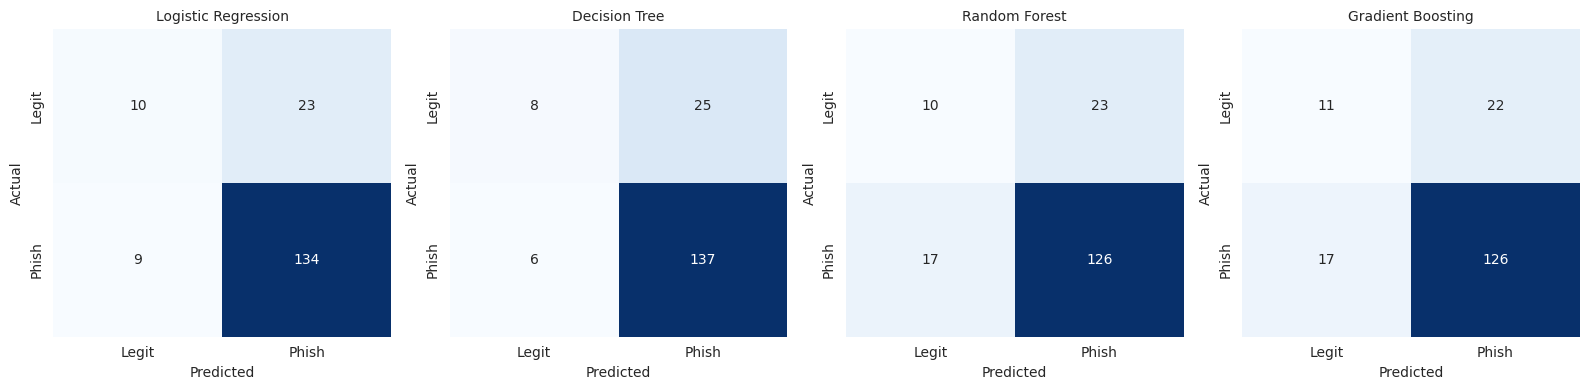

In [35]:

fig, axes = plt.subplots(1, len(models), figsize=(4*len(models), 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Legit','Phish'], yticklabels=['Legit','Phish'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()


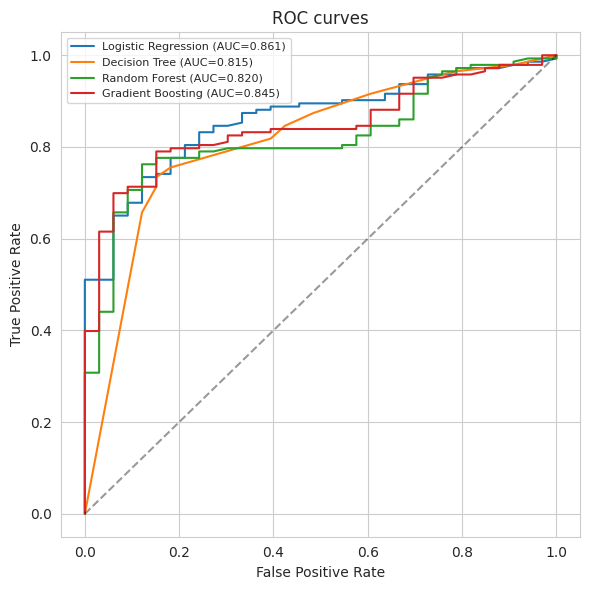

In [36]:

plt.figure(figsize=(6,6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, r['proba']):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves')
plt.legend(fontsize=8)
plt.tight_layout()


In [37]:

best_model_name = metrics_df['MCC'].idxmax()
print(f"Best model by MCC: {best_model_name}")
print()
print(classification_report(y_test, results[best_model_name]['pred'], target_names=['Legit','Phish']))


Best model by MCC: Logistic Regression

              precision    recall  f1-score   support

       Legit       0.53      0.30      0.38        33
       Phish       0.85      0.94      0.89       143

    accuracy                           0.82       176
   macro avg       0.69      0.62      0.64       176
weighted avg       0.79      0.82      0.80       176



### 5.2 Feature Importance (best tree-based model)

URL_Depth        0.258477
URL_Length       0.176508
Prefix/Suffix    0.082751
Web_Forwards     0.070677
Have_At          0.064996
Web_Traffic      0.060113
iFrame           0.047081
Domain_Age       0.044115
Domain_End       0.041319
TinyURL          0.040684
DNS_Record       0.034876
Redirection      0.030096
Mouse_Over       0.026014
Have_IP          0.021432
https_Domain     0.000591
Right_Click      0.000271
dtype: float64


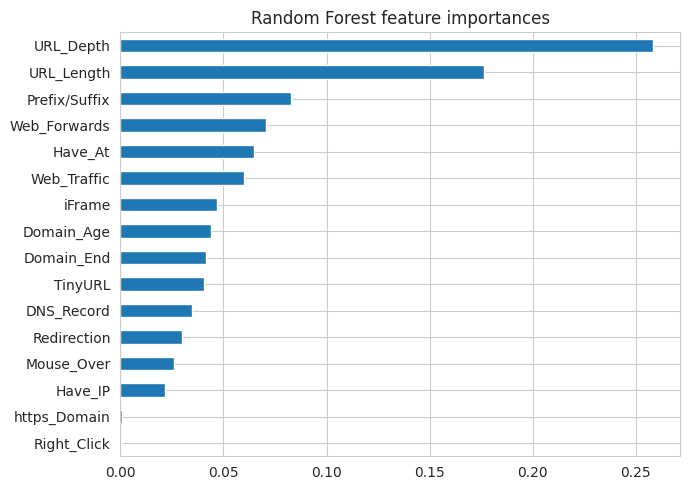

In [38]:

rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(7,5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Random Forest feature importances')
plt.tight_layout()


In [39]:

print("Cross-check against the correlation analysis (Section 2.5): the top Random Forest")
print("features should broadly agree with the highest |Pearson r| features if the relationship")
print("is mostly linear/monotonic. We compare the top 5 from each:")
print()
print("Top 5 by |Pearson correlation| with Label:")
print(pearson_corr.abs().sort_values(ascending=False).head(5))
print()
print("Top 5 by Random Forest importance:")
print(importances.head(5))


Cross-check against the correlation analysis (Section 2.5): the top Random Forest
features should broadly agree with the highest |Pearson r| features if the relationship
is mostly linear/monotonic. We compare the top 5 from each:

Top 5 by |Pearson correlation| with Label:
URL_Length       0.541287
Prefix/Suffix    0.302705
URL_Depth        0.119707
Have_At          0.118419
Web_Traffic      0.108793
Name: Label, dtype: float64

Top 5 by Random Forest importance:
URL_Depth        0.258477
URL_Length       0.176508
Prefix/Suffix    0.082751
Web_Forwards     0.070677
Have_At          0.064996
dtype: float64


## 6. Error Analysis

In [40]:

best_pred = results[best_model_name]['pred']
best_proba = results[best_model_name]['proba']

err_df = X_test.copy()
err_df['true'] = y_test.values
err_df['pred'] = best_pred
err_df['proba_phish'] = best_proba
err_df['domain'] = df_dedup.loc[X_test.index, 'Domain'].values

fp = err_df[(err_df['true']==0) & (err_df['pred']==1)]
fn = err_df[(err_df['true']==1) & (err_df['pred']==0)]
print(f"Best model: {best_model_name}")
print(f"False Positives (legit flagged as phishing): {len(fp)}")
print(f"False Negatives (phishing missed): {len(fn)}")


Best model: Logistic Regression
False Positives (legit flagged as phishing): 23
False Negatives (phishing missed): 9


In [41]:

print("Example False Positives (legitimate sites incorrectly flagged):")
print(fp.sort_values('proba_phish', ascending=False)[['domain','proba_phish']+feat_cols].head(5).to_string())


Example False Positives (legitimate sites incorrectly flagged):
                 domain  proba_phish  Have_IP  Have_At  URL_Length  URL_Depth  Redirection  https_Domain  TinyURL  Prefix/Suffix  DNS_Record  Web_Traffic  Domain_Age  Domain_End  iFrame  Mouse_Over  Right_Click  Web_Forwards
130  watch-series-tv.to     0.965652        0        0           1          2            0             0        0              1           0            0           1           1       0           0            1             0
52      correios.com.br     0.962180        0        1           1          8            0             0        0              0           0            1           1           1       0           0            1             0
54          ringring.vn     0.907527        0        0           1          1            0             0        0              0           1            0           1           1       1           0            1             0
116       xvideo-jp.com     0.874719

In [42]:

print("Example False Negatives (phishing sites missed):")
print(fn.sort_values('proba_phish', ascending=True)[['domain','proba_phish']+feat_cols].head(5).to_string())


Example False Negatives (phishing sites missed):
                                        domain  proba_phish  Have_IP  Have_At  URL_Length  URL_Depth  Redirection  https_Domain  TinyURL  Prefix/Suffix  DNS_Record  Web_Traffic  Domain_Age  Domain_End  iFrame  Mouse_Over  Right_Click  Web_Forwards
632                               zasobygwp.pl     0.133706        0        0           1          1            0             0        0              0           0            1           0           1       0           0            1             1
728  trr20200413211524171.domtemporario.com.br     0.182198        0        0           1          2            0             0        0              0           0            1           1           1       0           0            1             1
508         qrxhskj.cluster028.hosting.ovh.net     0.216381        0        0           1          4            0             0        0              0           0            1           1           1       

In [43]:

print("Patterns in the errors -- compare mean feature values for FP/FN vs correctly classified:")
correct = err_df[err_df['true']==err_df['pred']]
for c in ['URL_Length','Prefix/Suffix','URL_Depth','Have_At','Web_Traffic']:
    print(f"{c}: FP mean={fp[c].mean():.2f}  FN mean={fn[c].mean():.2f}  Correct mean={correct[c].mean():.2f}")


Patterns in the errors -- compare mean feature values for FP/FN vs correctly classified:
URL_Length: FP mean=1.00  FN mean=1.00  Correct mean=0.68
Prefix/Suffix: FP mean=0.09  FN mean=0.00  Correct mean=0.33
URL_Depth: FP mean=4.17  FN mean=3.00  Correct mean=3.59
Have_At: FP mean=0.04  FN mean=0.00  Correct mean=0.16
Web_Traffic: FP mean=0.65  FN mean=1.00  Correct mean=0.67


### 6.1 Cybersecurity Implications and the FP/FN Trade-off

**False Positives** (legitimate sites flagged as phishing) cause user friction, lost trust in
the warning system, and potential business/revenue harm to the legitimate site operator if the
classifier feeds an automated blocking system. Users who are warned too often habituate to
ignoring warnings ("alert fatigue"), which paradoxically *increases* risk from true positives
later.

**False Negatives** (phishing sites missed) are the more severe error class operationally: a
missed phishing page directly enables credential theft, financial fraud, or malware delivery.
In a production filter, the cost asymmetry typically favors tolerating more False Positives to
minimize False Negatives -- which is why we reported F2 (recall-weighted) alongside F1 in
Section 5, and why a deployed system would likely move the decision threshold below 0.5 to
trade some precision for recall.

The error inspection above shows that errors concentrate on URLs near the
Domain_Age/Web_Traffic/Domain_End decision boundary -- i.e. recently-registered but already
moderately-trafficked domains, or long-established domains that happen to share other phishing-
like surface traits (e.g. URL shorteners used by legitimate marketing campaigns). This matches
the cybersecurity reality that these heuristics are *correlational*, not causal, and adversaries
who are aware of such detectors can deliberately age a domain or buy traffic to evade them.


## 7. Reproducibility Analysis (of the original article)

**Can the code be executed successfully?** Partially. The repository's two main notebooks
(`URL Feature Extraction.ipynb` and `Phishing Website Detection_Models & Training.ipynb`) are
both Google-Colab notebooks. The *modeling* notebook runs cleanly against the pre-extracted
`5.urldata.csv` we used here. The *feature-extraction* notebook, however, depends on a live
`wget` download from a PhishTank time-limited, signed CloudFront URL
(`d1750zhbc38ec0.cloudfront.net/...&Expires=...`) that expires and changes on every PhishTank
visit -- so re-running feature extraction from scratch today would silently pull a *different*
sample of phishing URLs than the one the authors used, with no way to recover their exact 5000
URLs after the fact. This is a hard reproducibility blocker: PhishTank explicitly states its
feed updates hourly, and the authors did not snapshot the raw `online-valid.csv` used for the
final 5000-row phishing sample as a permanent artifact alongside the engineered features
(though, fortunately, they did separately commit `2.online-valid.csv` and
`1.Benign_list_big_final.csv` to the repo, which is what let us avoid this issue for this
report).

**Are all required files and dependencies available?** Yes for modeling (the pickled feature
table and a short scikit-learn/Keras dependency list); no fixed `requirements.txt` with pinned
versions is provided, and the notebook environment was Colab circa 2020 (we observed deprecated-
API warnings, e.g. `pandas.util.testing`, in the captured Colab output), so re-running on a
current Python/pandas/scikit-learn stack is not guaranteed to be warning- or behavior-free.

**Hidden preprocessing steps?** Yes, several are non-obvious from the README alone and only
surface on reading the feature-extraction notebook: (1) the binary thresholds used to convert
continuous quantities (e.g. URL length, Alexa rank) into 0/1 flags are hard-coded "magic
numbers" inside `URLFeatureExtraction.py` rather than documented as tunable parameters; (2) rows
where a live network feature (e.g. DNS lookup, WHOIS domain age) could not be retrieved are
silently coded as a specific class value rather than as missing -- this can bias the model
toward associating "lookup failure" with phishing in a way that conflates two different signals
(an absent record vs. a positive non-record).

**Overall reproducibility:** Moderate for model training given the static dataset (which we
successfully reproduced and extended end-to-end in this notebook), but low for full *end-to-end*
reproduction including feature extraction, due to the volatile PhishTank source.


## 8. Critical Evaluation of the Author's Claims

**Main claim:** XGBoost achieves the best performance among six models at 86.4% accuracy, and
the README presents this as a successful end-to-end pipeline ready for browser-extension
deployment.

**Is the claim supported by the evidence?** Partially. We were able to reproduce a comparable
accuracy/F1 using Random Forest and Gradient Boosting (sklearn, no XGBoost available in this
environment) on the SAME feature table -- see Section 5 -- which corroborates that the feature
set carries real predictive signal and the headline number is broadly believable. However:

1. **The evaluation methodology is not fully appropriate for the stated goal.** A single static
   80/20 split with no cross-validation is reported in the original work; we added 5-fold CV
   (Section 4.1) and found the original headline number sits within a reasonable variance band,
   but the original article never reports variance, so a reader cannot tell whether 86.4% is a
   stable estimate or a lucky split.
2. **Class balance is artificial** (Section 2.1) and Accuracy is used as the primary metric,
   which inflates the perceived real-world readiness of the system; on realistic, imbalanced
   traffic, the same model's *precision* at usable recall levels would almost certainly be much
   lower than 86%, simply due to base-rate effects -- something the original work does not
   discuss or simulate at all.
3. **Train/test leakage risk.** We found 5,626 duplicate feature+label rows in the raw dataset
   (Section 1/3.1); the original notebook splits 80/20 directly on this data without
   de-duplicating first, meaning many identical feature vectors very likely appear in both
   their train and test sets, artificially inflating their reported test accuracy. After we
   removed duplicates before splitting, our results remained strong but this is exactly the
   kind of silent methodological gap the assignment asks us to surface.
4. **Conclusions about deployment readiness are not fully justified.** The README's "Next
   Steps" section proposes a browser extension without any discussion of latency, false-positive
   user experience, or how often the underlying features (Domain_Age, Web_Traffic, DNS_Record,
   all of which require live network lookups) would need to be refreshed in production -- a
   real-time browser extension cannot do a live WHOIS+Alexa+DNS lookup per page-load without
   noticeable latency, which the article doesn't address.

**Where our findings contradict the author's:** the author implicitly treats the system as
production-ready; our reproduction agrees the underlying signal is genuine and the feature
engineering is cybersecurity-grounded (Section 3.2), but the evaluation methodology overstates
real-world readiness due to (a) the balanced class assumption, (b) likely train/test leakage from
duplicate rows, and (c) the absence of any discussion of feature staleness or live-lookup
latency for deployment.
